1. Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
import joblib

2. Load Data

In [2]:
#load data dan menampilkan 5 baris data teratas
df = pd.read_csv("Dataset-Bank-Customer-Churn-Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


- customer_id – nilai unik yang digunakan untuk mengidentifikasi setiap pelanggan
- credit_score – skor kredit pelanggan yang mencerminkan tingkat kelayakan kredit
- country – negara tempat pelanggan terdaftar atau berdomisili
- gender – jenis kelamin pelanggan (Laki-laki, Perempuan)
- age – usia pelanggan dalam satuan tahun
- tenure – jumlah tahun pelanggan telah menjadi nasabah bank
- balance – saldo rekening pelanggan saat ini
- products_number – jumlah produk bank yang digunakan pelanggan (misalnya tabungan, kartu kredit, pinjaman)
- credit_card – menunjukkan apakah pelanggan memiliki kartu kredit (1 = Ya, 0 = Tidak)
- active_member – menunjukkan apakah pelanggan merupakan anggota aktif bank (1 = Aktif, 0 = Tidak aktif)
- estimated_salary – estimasi pendapatan tahunan pelanggan
- churn – variabel output / target yang menunjukkan apakah pelanggan berhenti menggunakan layanan bank atau tidak (1 = Churn, 0 = Tidak churn)

In [4]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# Mengecek dataset menggunakan isnull().sum()
df.duplicated().sum()

np.int64(0)

In [6]:
# Mengecek dataset menggunakan duplicated().sum()
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

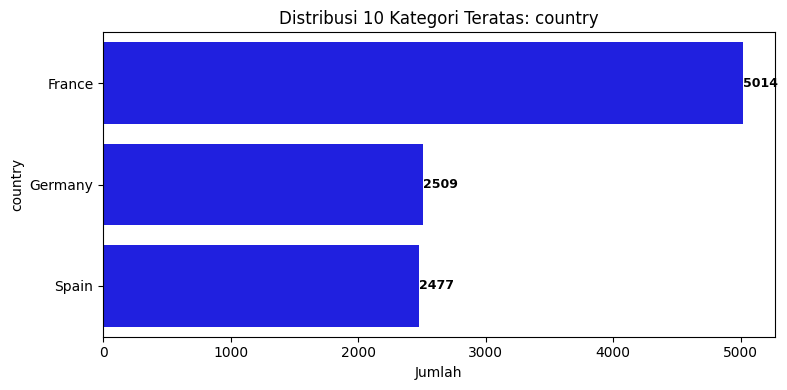

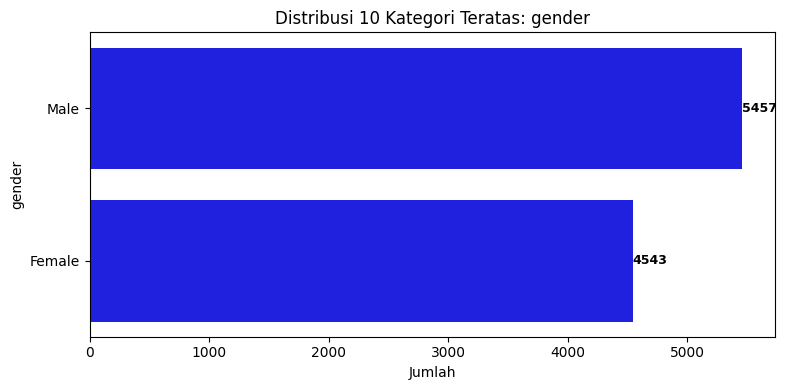

In [7]:
kategorikal = df.select_dtypes(include=[object])

for col in kategorikal:
    plt.figure(figsize=(8,4))
    
    # Ambil 10 kategori paling sering muncul
    top10 = df[col].value_counts().head(10)
    
    sns.barplot(
        x=top10.values, 
        y=top10.index, 
        color='blue'
    )
    
    #angka di ujung bar
    for i, v in enumerate(top10.values):
        plt.text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight="bold")
    
    plt.title(f"Distribusi 10 Kategori Teratas: {col}")
    plt.xlabel("Jumlah")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

3. Preprocessing

In [8]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal
kategorikal = df.select_dtypes(include=[object])
encoders = {}  
for col in kategorikal:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print("Hasil Encoding dengan LabelEncoder:")
df.head()

Hasil Encoding dengan LabelEncoder:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#menghapus kolom customer_id karena tidak diperlukan untuk pelatihan model
df.drop("customer_id", axis=1, inplace=True)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


4. Split Data

In [10]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
#nyoba 
#model = DecisionTreeClassifier(
#    criterion="entropy",
#    max_depth=3,
#    min_samples_split=10,
#    min_samples_leaf=5,
#    random_state=42
#)

#model.fit(X_train, y_train)

#plt.figure(figsize=(24, 12))
#plot_tree(
#    model,
#    feature_names=X.columns,
#    class_names=["Tidak Churn", "Churn"],
#    filled=True,
#    rounded=True
#)
#plt.show()


5. Modelling

In [23]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [None, "sqrt", "log2"],
    "splitter": ["best", "random"]
}

In [24]:
dt = DecisionTreeClassifier(random_state=42)

In [25]:
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [26]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [27]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}


In [28]:
best_model = grid.best_estimator_

In [ ]:
# Classification report
print("\nHasil Klasifikasi:")
print(classification_report(y_test, y_pred, digits=4))

6. Evaluasi

Hasil Evaluasi Decision Tree
Accuracy: 0.855

Hasil Klasifikasi:
              precision    recall  f1-score   support

           0     0.8660    0.9695    0.9149      1607
           1     0.7562    0.3868    0.5118       393

    accuracy                         0.8550      2000
   macro avg     0.8111    0.6781    0.7133      2000
weighted avg     0.8445    0.8550    0.8357      2000


Confusion Matrix:
[[1558   49]
 [ 241  152]]


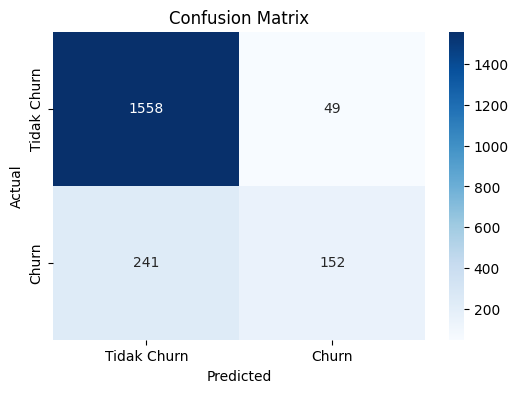

In [29]:
y_pred = best_model.predict(X_test)

print("Hasil Evaluasi Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nHasil Klasifikasi:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Tidak Churn', 'Churn'],
    yticklabels=['Tidak Churn', 'Churn']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

7. Simpan Model

In [30]:
joblib.dump((best_model, X.columns), "model.pkl")
print("Model saved!")

Model saved!
